In [1]:
# written-test-2020-09-11-exam-mba.csv

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules 

In [3]:
df = pd.read_csv("written-test-2020-09-11-exam-mba.csv")
df.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,Item 10,Item 11,Item 12,Item 13,Item 14,Item 15,Item 16,Item 17,Item 18,Item 19,Item 20,Item 21,Item 22,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe()

,Item(s)
count,9835.000000
mean,4.409456
std,3.589385
min,1.000000
25%,2.000000
50%,3.000000
75%,6.000000
max,32.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9835 entries, 0 to 9834
Data columns (total 33 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Item(s)  9835 non-null   int64 
 1   Item 1   9835 non-null   object
 2   Item 2   7676 non-null   object
 3   Item 3   6033 non-null   object
 4   Item 4   4734 non-null   object
 5   Item 5   3729 non-null   object
 6   Item 6   2874 non-null   object
 7   Item 7   2229 non-null   object
 8   Item 8   1684 non-null   object
 9   Item 9   1246 non-null   object
 10  Item 10  896 non-null    object
 11  Item 11  650 non-null    object
 12  Item 12  468 non-null    object
 13  Item 13  351 non-null    object
 14  Item 14  273 non-null    object
 15  Item 15  196 non-null    object
 16  Item 16  141 non-null    object
 17  Item 17  95 non-null     object
 18  Item 18  66 non-null     object
 19  Item 19  52 non-null     object
 20  Item 20  38 non-null     object
 21  Item 21  29 non-null     object
 22  

Remove transactions with a single item

In [30]:
df = df[df["Item(s)"] > 1]

print(df.shape)

(7676, 33)


What get_dummies() actually does

pd.get_dummies() performs one-hot encoding:

Every unique categorical value becomes a column

Presence → 1

Absence → 0

Note: get_dummies() works column-wise, not row-wise.

So if we apply it directly to your dataframe: It will treat each Item column separately, which is usually NOT what we want for market-basket analysis.

Extract only item columns

In [31]:
items_df = df.iloc[:, 1:]
items_df

,Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,Item 10,Item 11,Item 12,Item 13,Item 14,Item 15,Item 16,Item 17,Item 18,Item 19,Item 20,Item 21,Item 22,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,whole milk,butter,yogurt,rice,abrasive cleaner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9829,tropical fruit,other vegetables,domestic eggs,zwieback,ketchup,soda,dishes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9830,sausage,chicken,beef,hamburger meat,citrus fruit,grapes,root vegetables,whole milk,butter,whipped/sour cream,flour,coffee,red/blush wine,salty snack,chocolate,hygiene articles,napkins,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9832,chicken,citrus fruit,other vegetables,butter,yogurt,frozen dessert,domestic eggs,rolls/buns,rum,cling film/bags,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9833,semi-finished bread,bottled water,soda,bottled beer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Convert wide format to long format

In [32]:
stacked_items = items_df.stack()

In [33]:
stacked_items

0     Item 1           citrus fruit
      Item 2    semi-finished bread
      Item 3              margarine
      Item 4            ready soups
1     Item 1         tropical fruit
                       ...         
9834  Item 1                chicken
      Item 2         tropical fruit
      Item 3       other vegetables
      Item 4                vinegar
      Item 5          shopping bags
Length: 41208, dtype: object

One-hot encode the items

In [35]:
df1 = pd.get_dummies(stacked_items, prefix='', prefix_sep='', dummy_na=False)
df1.head()

Instant food products  UHT-milk  ...  yogurt  zwieback
0 Item 1                  False     False  ...   False     False
  Item 2                  False     False  ...   False     False
  Item 3                  False     False  ...   False     False
  Item 4                  False     False  ...   False     False
1 Item 1                  False     False  ...   False     False

[5 rows x 169 columns]

Now at this point we have our columns as distinct items (i.e Citrus Fruit) and rows containing the relevant occurences respectively

In [37]:
# groupby(level=0) is used to group by the first level of a MultiIndex.
# Group by transaction and convert to boolean basket

basket = df1.groupby(level=0).max().astype(bool)

basket.head(10)

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,cake bar,candles,candy,canned beer,canned fish,canned fruit,canned vegetables,cat food,cereals,chewing gum,chicken,chocolate,chocolate marshmallow,citrus fruit,cleaner,cling film/bags,cocoa drinks,coffee,condensed milk,cooking chocolate,cookware,cream,...,salty snack,sauces,sausage,seasonal products,semi-finished bread,shopping bags,skin care,sliced cheese,snack products,soap,soda,soft cheese,softener,sound storage medium,soups,sparkling wine,specialty bar,specialty cheese,specialty chocolate,specialty fat,specialty vegetables,spices,spread cheese,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
5,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
7,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True

Step 0 and 1 are done we are heading to step 2

In [38]:
print("Number of column names of the output dataframe are the distinct items are {}".format(len(basket.columns.unique())))

Number of column names of the output dataframe are the distinct items are 169


In [42]:
print(basket.columns[:10])

Index(['Instant food products', 'UHT-milk', 'abrasive cleaner',
       'artif. sweetener', 'baby cosmetics', 'baby food', 'bags',
       'baking powder', 'bathroom cleaner', 'beef'],
      dtype='object')


In [39]:
basket.head(5)

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,cake bar,candles,candy,canned beer,canned fish,canned fruit,canned vegetables,cat food,cereals,chewing gum,chicken,chocolate,chocolate marshmallow,citrus fruit,cleaner,cling film/bags,cocoa drinks,coffee,condensed milk,cooking chocolate,cookware,cream,...,salty snack,sauces,sausage,seasonal products,semi-finished bread,shopping bags,skin care,sliced cheese,snack products,soap,soda,soft cheese,softener,sound storage medium,soups,sparkling wine,specialty bar,specialty cheese,specialty chocolate,specialty fat,specialty vegetables,spices,spread cheese,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
5,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False


In [46]:
print("number of transactions: {} and of distinct items :{}".format(basket.shape[0], basket.shape[1]))

number of transactions: 7676 and of distinct items :169


We now need to find a value of min_support such that the apriori algorithm generates at least 8 frequent itemsets with at least 2 items.

In [47]:
min_frequent_itemsets = 8
min_items = 2

Search for a valid min_support

In [58]:
min_supports = np.arange(0.20, 0.01, step =- 0.01)
best_support = None
num_of_itemsets = None

for min_sup in min_supports:
    frequent_itemsets = apriori(basket, min_sup, use_colnames=True)
    
    # print(frequent_itemsets)
    
    # Keep only itemsets with at least 2 items
    items_set_len_2 = frequent_itemsets[
        frequent_itemsets["itemsets"].apply(len) >=2
    ]
    
    # print(items_set_len_2)
    
    if (len(items_set_len_2) >= 8 ):
        best_support = min_sup
        num_of_itemsets = len(items_set_len_2)
        break
    
print(f"min_support: {best_support} - number of itemsets with at least 2 items: {num_of_itemsets}")

min_support: 0.04999999999999988 - number of itemsets with at least 2 items: 9


step 6

find the minimum metric threshold such that at least 10
association rules are extracted from the frequent itemsets found
(5 points)
• use "confidence" as metric and output the line below:
• Metric: "confidence" - min_metric: 0.xxxx - Number of
rules: n

In [62]:
selected_metric = "confidence"
min_rules = 10
min_confidence = np.arange(1, 0.1, step =- 0.01)

frequent_itemsets = apriori(basket, min_sup, use_colnames=True)
selected_confidence_min = 0
selected_rule = None

for mfc in min_confidence:
    
    rules = association_rules(frequent_itemsets, metric=selected_metric, min_threshold=mfc)
    # print(rules)
    
    if len(rules) >= min_rules:
        selected_confidence_min = mfc
        selected_rule = len(rules)
        break
    
    
print("Metric: {} - min_metric: {:0.4f} - Number of rules: {}".format(
    selected_metric,
    selected_confidence_min,
    selected_rule
))



Metric: confidence - min_metric: 0.2500 - Number of rules: 10


In [64]:
rules = association_rules(frequent_itemsets, metric=selected_metric, min_threshold=selected_confidence_min)

sorted_rules = rules.sort_values(by=selected_metric, ascending=False).reset_index(drop=True)
display(sorted_rules)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(root vegetables),(whole milk),0.136399,0.311621,0.062663,0.459408,1.474254,1.0,0.020158,1.273380,0.372499,0.162610,0.214689,0.330247
1,(root vegetables),(other vegetables),0.136399,0.239838,0.060709,0.445081,1.855754,1.0,0.027995,1.369861,0.533968,0.192403,0.269999,0.349102
2,(yogurt),(whole milk),0.173528,0.311621,0.071782,0.413664,1.327459,1.0,0.017707,1.174035,0.298475,0.173653,0.148237,0.322007
3,(tropical fruit),(whole milk),0.131449,0.311621,0.054195,0.412289,1.323049,1.0,0.013233,1.171290,0.281123,0.139363,0.146240,0.293101
4,(other vegetables),(whole milk),0.239838,0.311621,0.095883,0.399783,1.282915,1.0,0.021145,1.146884,0.290103,0.210466,0.128072,0.353738
5,(rolls/buns),(whole milk),0.221470,0.311621,0.072564,0.327647,1.051429,1.0,0.003549,1.023836,0.062828,0.157567,0.023281,0.280253
6,(yogurt),(other vegetables),0.173528,0.239838,0.055628,0.320571,1.336610,1.0,0.014009,1.118823,0.304715,0.155499,0.106204,0.276255
7,(whole milk),(other vegetables),0.311621,0.239838,0.095883,0.307692,1.282915,1.0,0.021145,1.098011,0.320354,0.210466,0.089262,0.353738
8,(other vegetables),(root vegetables),0.239838,0.136399,0.060709,0.253123,1.855754,1.0,0.027995,1.156283,0.606628,0.192403,0.135160,0.349102
9,(soda),(whole milk),0.203101,0.311621,0.051329,0.252726,0.811006,1.0,-0.011962,0.921187,-0.226263,0.110768,-0.085555,0.208721


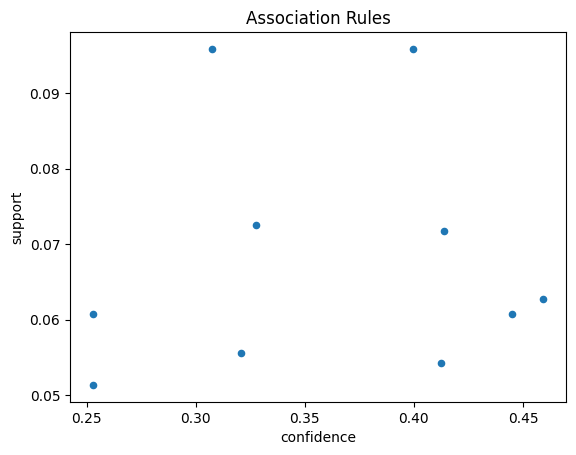

In [68]:
sorted_rules.plot.scatter(selected_metric, "support", title="Association Rules");

scatter plot the rules by confidence and support, labelling the
points with the index value of the corresponding rule

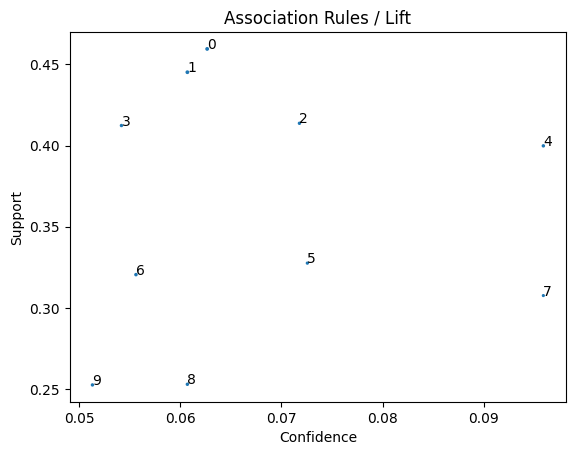

In [73]:
s = [1.8 ** n for n in rules.lift]

fig, ax = plt.subplots()

ax.set_xlabel("Confidence")
ax.set_ylabel("Support")

ax.set_title("Association Rules / Lift")

for i, txt in enumerate(sorted_rules.index):
    ax.annotate(txt, (sorted_rules["support"][i], sorted_rules["confidence"][i]))
    
plt.scatter(sorted_rules["support"], sorted_rules["confidence"], s=s)